### 1. Initialisation et chargement des données

In [16]:
#  Import des bibliothèques nécessaires
import pandas as pd                  # Manipulation de données (DataFrame)
import numpy as np                   # Calculs numériques
import matplotlib.pyplot as plt      # Visualisation (graphiques)
import matplotlib.patches as mpatches  # Ajout d'éléments personnalisés dans les graphes
import seaborn as sns                # Visualisation avancée
from pathlib import Path             # Gestion des chemins de fichiers
from sklearn.preprocessing import LabelEncoder  # Encodage des variables catégorielles

#  Configuration du style des graphiques
sns.set_theme(style="whitegrid", palette="husl", font_scale=1.1)  
# style = fond avec grille, palette = couleurs, font_scale = taille du texte

plt.rcParams['figure.dpi'] = 110  
# Améliore la qualité (résolution) des figures

#  Dictionnaire de couleurs pour les classes
C = {
    'sain': '#2ecc71',   # Vert pour les personnes saines
    'malade': '#e74c3c'  # Rouge pour les personnes malades
}

#  Définition des chemins
DATA_PATH = Path("../data/raw/heart_disease_uci.csv")  # Chemin du dataset
FIGS_PATH = Path('../reports/figures')              # Dossier pour sauvegarder les figures

#  Création du dossier figures s'il n'existe pas
FIGS_PATH.mkdir(parents=True, exist_ok=True)

#  Chargement des données
df_raw = pd.read_csv(DATA_PATH)  # Lecture du fichier CSV
df = df_raw.copy()               # Copie pour éviter de modifier les données originales

#  Création de la variable cible (target)
df['target']       = (df['num'] > 0).astype(int)
# Si num > 0 → malade (1)
# Sinon → sain (0)

#  Ajout d'une version texte de la target
df['target_label'] = df['target'].map({
    0: 'Sain',
    1: 'Malade'
})
# Permet d'avoir des labels lisibles pour les graphiques

#  Définition des colonnes numériques
NUM_COLS = [
    'age',        # âge
    'trestbps',   # pression sanguine au repos
    'chol',       # cholestérol
    'thalch',     # fréquence cardiaque max
    'oldpeak',    # dépression ST
    'ca'          # nombre de vaisseaux colorés
]

#  Définition des colonnes catégorielles
CAT_COLS = [
    'sex',        # sexe
    'cp',         # type de douleur thoracique
    'restecg',    # ECG au repos
    'slope',      # pente ST
    'thal'        # type de thalassémie
]

#  Affichage de la taille du dataset
print(f'Shape : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes')
# shape[0] = nombre de lignes
# shape[1] = nombre de colonnes

#  Affichage des 8 premières lignes
df_raw.head(8)
# Permet de voir un aperçu rapide des données

Shape : 920 lignes × 16 colonnes


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0


### 1. Vue d'ensemble

In [17]:
print('--- Types ---')
print(df_raw.dtypes)
print()
print('--- Valeurs uniques (catégorielles) ---')
for col in ['sex', 'cp', 'restecg', 'slope', 'thal', 'dataset', 'fbs', 'exang']:
    print(f'  {col:12s}: {list(df_raw[col].dropna().unique())}')

--- Types ---
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

--- Valeurs uniques (catégorielles) ---
  sex         : ['Male', 'Female']
  cp          : ['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
  restecg     : ['lv hypertrophy', 'normal', 'st-t abnormality']
  slope       : ['downsloping', 'flat', 'upsloping']
  thal        : ['fixed defect', 'normal', 'reversable defect']
  dataset     : ['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
  fbs         : [True, False]
  exang       : [False, True]


### 2. Analyse de la cible

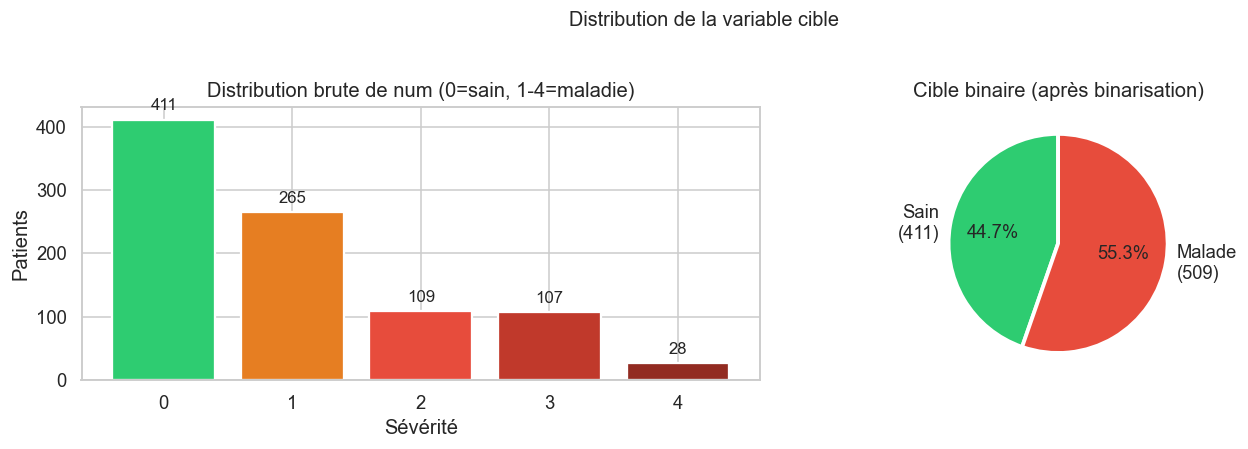


Ratio malades : 55.3%  →  léger déséquilibre, traitement par SMOTE nécessaire


In [21]:
fig,axes =plt.subplots(1,2,figsize=(13,4))  # créer une figure avec 2 graphiques côte à côte

counts_raw = df['num'].value_counts().sort_index()  # compter les valeurs de 'num' et trier
palette = ['#2ecc71', '#e67e22', '#e74c3c', '#c0392b', '#922b21']  # couleurs selon la sévérité

bars = axes[0].bar(counts_raw.index.astype(str),counts_raw.values,  # créer le bar chart
                   color=palette,edgecolor='white',linewidth=1.5)  # style des barres
axes[0].bar_label(bars, padding=4,fontsize=11)  # afficher les valeurs au-dessus des barres
axes[0].set_title('Distribution brute de num (0=sain, 1-4=maladie)')  # titre du graphique
axes[0].set_xlabel('Sévérité')  # label axe X
axes[0].set_ylabel('Patients')  # label axe Y

counts_bin = df['target'].value_counts().sort_index()  # compter les classes binaires

axes[1].pie(counts_bin.values,  # créer le pie chart
            labels=[f'Sain\n({counts_bin[0]})', f'Malade\n({counts_bin[1]})'],  # labels avec nombre
            autopct='%1.1f%%',  # afficher les pourcentages
            colors=[C['sain'], C['malade']],  # couleurs depuis dictionnaire C
            startangle=90,  # rotation du graphique
            wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},  # style des bordures
            textprops={'fontsize': 12})  # taille du texte
axes[1].set_title('Cible binaire (après binarisation)')  # titre du pie chart

plt.suptitle('Distribution de la variable cible', fontsize=13, y=1.02)  # titre global
plt.tight_layout()  # ajuster les espacements
plt.savefig(FIGS_PATH / '01_target_distribution.png', dpi=150, bbox_inches='tight')  # sauvegarder l'image
plt.show()  
print(f'\nRatio malades : {df["target"].mean():.1%}  →  léger déséquilibre, traitement par SMOTE nécessaire')  # afficher le ratio des malades

### 3. Valeurs manquantes

=== Valeurs manquantes par variable ===
          Nb manquants  % manquants
ca                 611         66.4
thal               486         52.8
slope              309         33.6
fbs                 90          9.8
oldpeak             62          6.7
trestbps            59          6.4
exang               55          6.0
thalch              55          6.0
chol                30          3.3
restecg              2          0.2


C:\Users\hp\AppData\Local\Temp\ipykernel_16480\3729173860.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


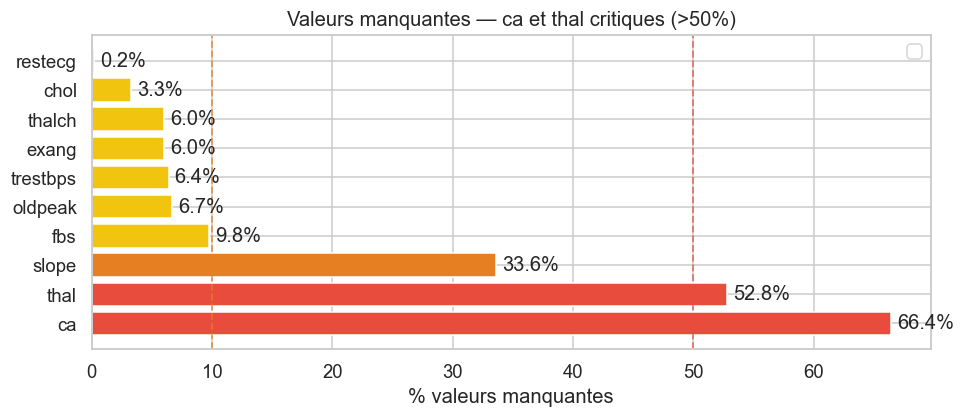


→ ca et thal : >50% manquant → imputation + flag binaire
→ slope : 34% → imputation par mode
→ autres < 10% → imputation standard


In [23]:
miss = df_raw.isnull().sum()  # nb valeurs manquantes
miss_pct = (miss / len(df_raw) * 100).round(1)  # % valeurs manquantes
miss_df = pd.DataFrame({'Nb manquants': miss, '% manquants': miss_pct})
miss_df = miss_df[miss_df['Nb manquants'] > 0].sort_values('% manquants', ascending=False)  # filtrer + trier

print('=== Valeurs manquantes par variable ===')
print(miss_df.to_string())

fig, ax = plt.subplots(figsize=(9, 4))

colors = ['#e74c3c' if p > 50 else '#e67e22' if p > 10 else '#f1c40f'  # couleurs selon seuil
          for p in miss_df['% manquants']]

bars = ax.barh(miss_df.index, miss_df['% manquants'], color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f'{p:.1f}%' for p in miss_df['% manquants']], padding=4)

ax.axvline(50, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)  # seuil critique
ax.axvline(10, color='#e67e22', linestyle='--', linewidth=1.2, alpha=0.7)  # seuil modéré

ax.set_xlabel('% valeurs manquantes')
ax.set_title('Valeurs manquantes — ca et thal critiques (>50%)')
ax.legend()

plt.tight_layout()
plt.savefig(FIGS_PATH / '02_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ ca et thal : >50% manquant → imputation + flag binaire')
print('→ slope : 34% → imputation par mode')
print('→ autres < 10% → imputation standard')

### 4. Valeurs aberrantes

=== Valeurs aberrantes ===
  chol = 0      → 172 patients  (cholestérol nul = impossible médicalement)
  trestbps = 0  → 1 patient   (pression artérielle nulle = impossible)
  oldpeak < 0   → 12 patients  (dépression ST négative = probablement saisie incorrecte)


C:\Users\hp\AppData\Local\Temp\ipykernel_16480\260876372.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_sain, data_malade], labels=['Sain', 'Malade'], patch_artist=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_16480\260876372.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_sain, data_malade], labels=['Sain', 'Malade'], patch_artist=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_16480\260876372.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_sain, data_malade], labels=['Sain', 'Malade'], patch_artist=True)
C:\Users\hp\AppData\Local\Temp\

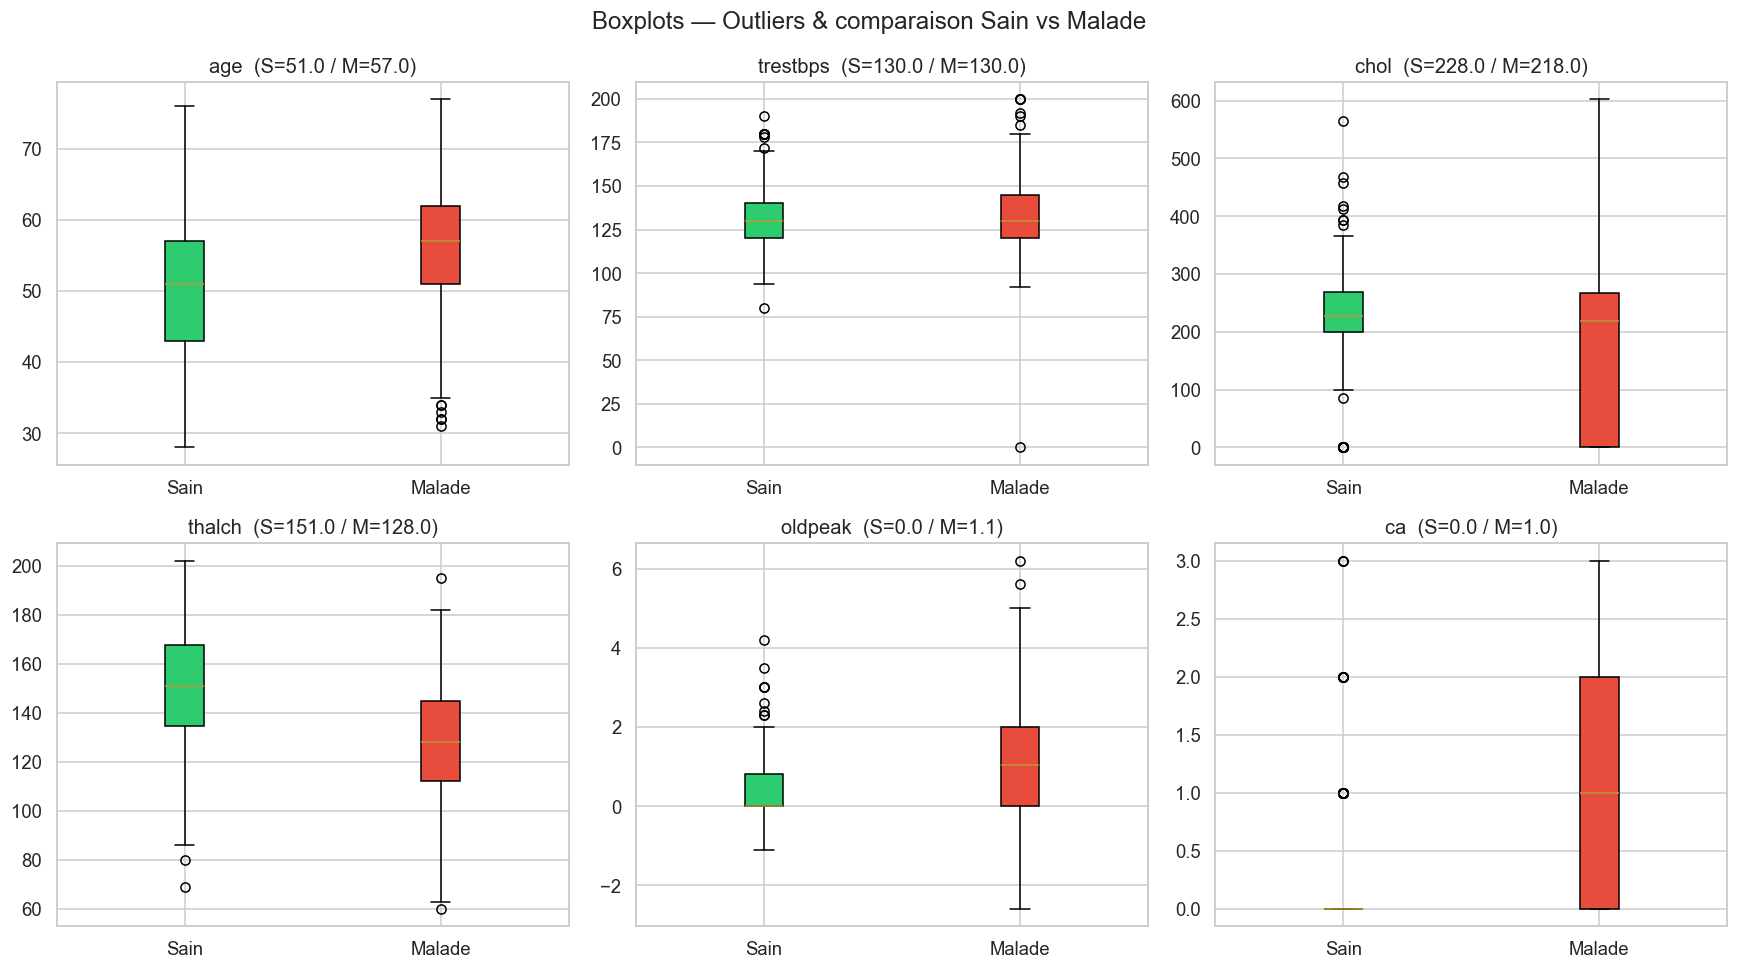

In [25]:
print('=== Valeurs aberrantes ===')  # titre

n_chol = (df_raw['chol'] == 0).sum()  # valeurs impossibles
n_bps  = (df_raw['trestbps'] == 0).sum()
n_old  = (df_raw['oldpeak'] < 0).sum()

print(f'  chol = 0      → {n_chol} patients  (cholestérol nul = impossible médicalement)')
print(f'  trestbps = 0  → {n_bps} patient   (pression artérielle nulle = impossible)')
print(f'  oldpeak < 0   → {n_old} patients  (dépression ST négative = probablement saisie incorrecte)')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))  # grille de boxplots

for ax, col in zip(axes.flat, NUM_COLS):
    data_sain   = df[df['target'] == 0][col].dropna()  # groupe sain
    data_malade = df[df['target'] == 1][col].dropna()  # groupe malade

    bp = ax.boxplot([data_sain, data_malade], labels=['Sain', 'Malade'], patch_artist=True)

    bp['boxes'][0].set_facecolor(C['sain'])
    bp['boxes'][1].set_facecolor(C['malade'])

    ax.set_title(f'{col}  (S={data_sain.median():.1f} / M={data_malade.median():.1f})')  # médianes

plt.suptitle('Boxplots — Outliers & comparaison Sain vs Malade')
plt.tight_layout()
plt.savefig(FIGS_PATH / '03_boxplots_outliers.png', dpi=150)
plt.show()

### 5. Distributions des variables numériques

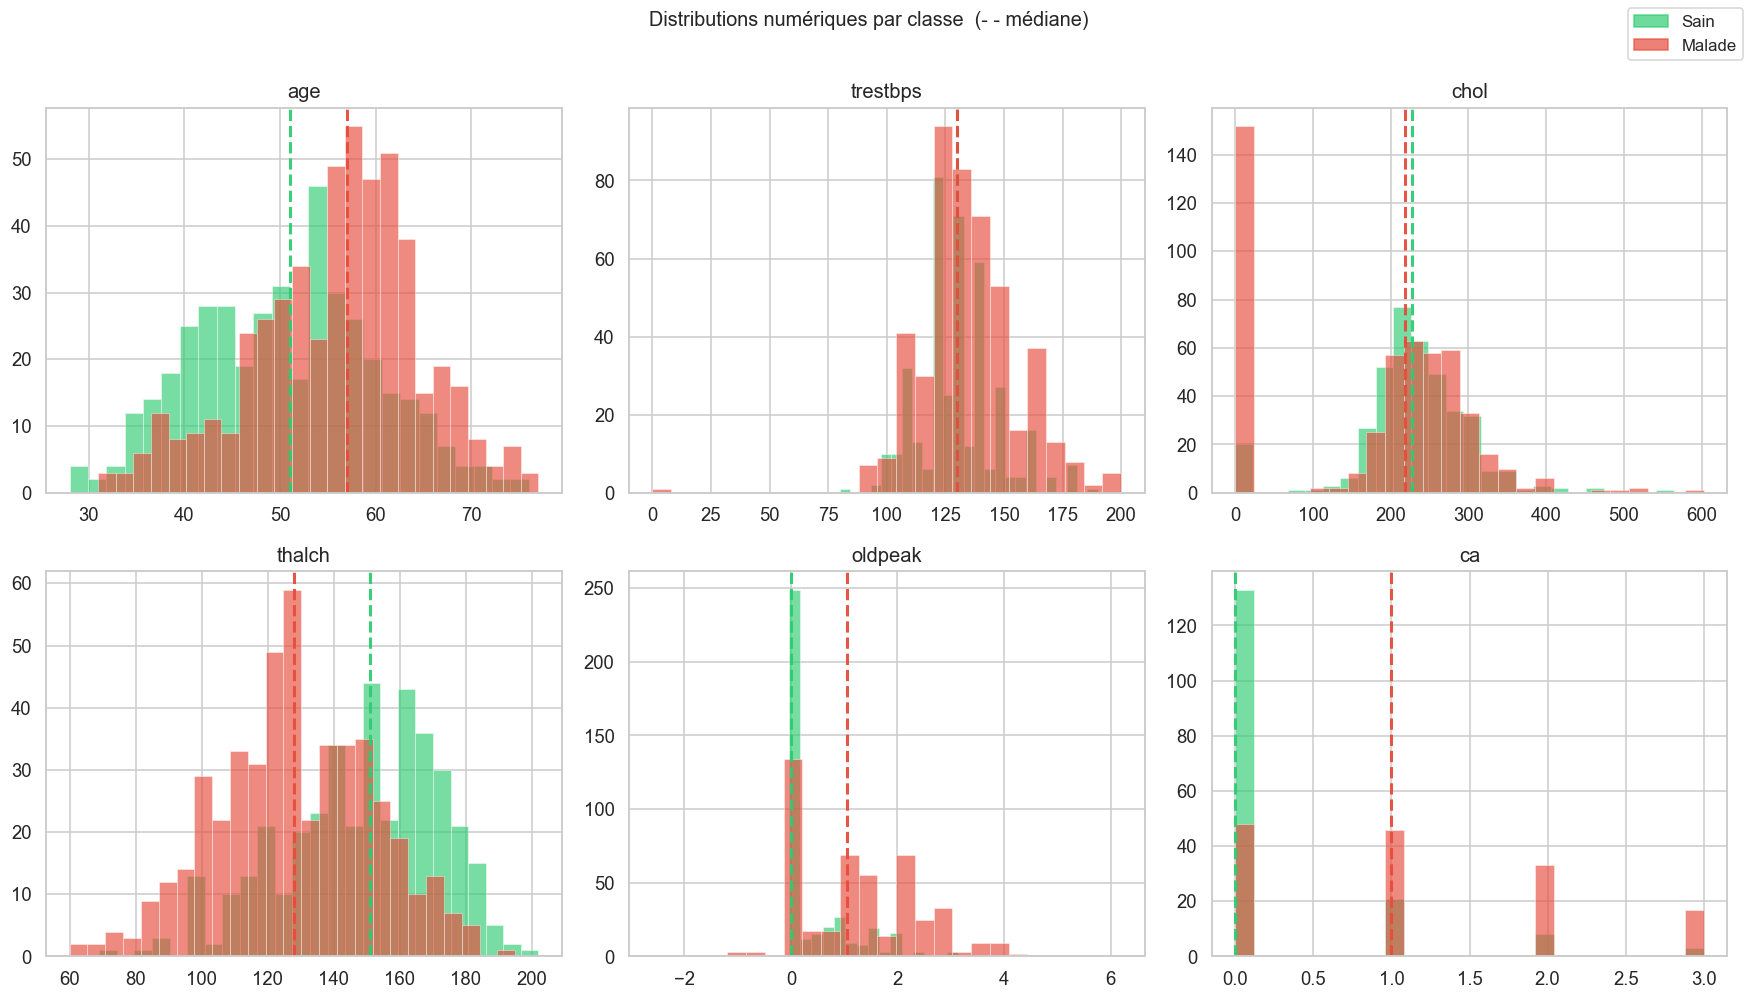

--- Médiane Sain / Malade ---


target,Sain,Malade
age,51.0,57.00
trestbps,130.0,130.00
chol,228.0,218.00
thalch,151.0,128.00
oldpeak,0.0,1.05
ca,0.0,1.00


In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))  # grille de graphiques
patch_s = mpatches.Patch(color=C['sain'],   alpha=0.7, label='Sain')  # légende sain
patch_m = mpatches.Patch(color=C['malade'], alpha=0.7, label='Malade')  # légende malade

for ax, col in zip(axes.flat, NUM_COLS):
    for val, color in [(0, C['sain']), (1, C['malade'])]:
        subset = df[df['target'] == val][col].dropna()  # données par classe
        ax.hist(subset, bins=25, alpha=0.65, color=color, edgecolor='white', linewidth=0.4)  # histogramme
        ax.axvline(subset.median(), color=color, linestyle='--', linewidth=2, alpha=0.95)  # médiane
    ax.set_title(col)

fig.legend(handles=[patch_s, patch_m], loc='upper right', fontsize=11)
plt.suptitle('Distributions numériques par classe  (- - médiane)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_PATH / '04_num_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('--- Médiane Sain / Malade ---')
df.groupby('target')[NUM_COLS].median().T.rename(columns={0:'Sain', 1:'Malade'})  # tableau des médianes

### 6. Variables catégorielles vs cible

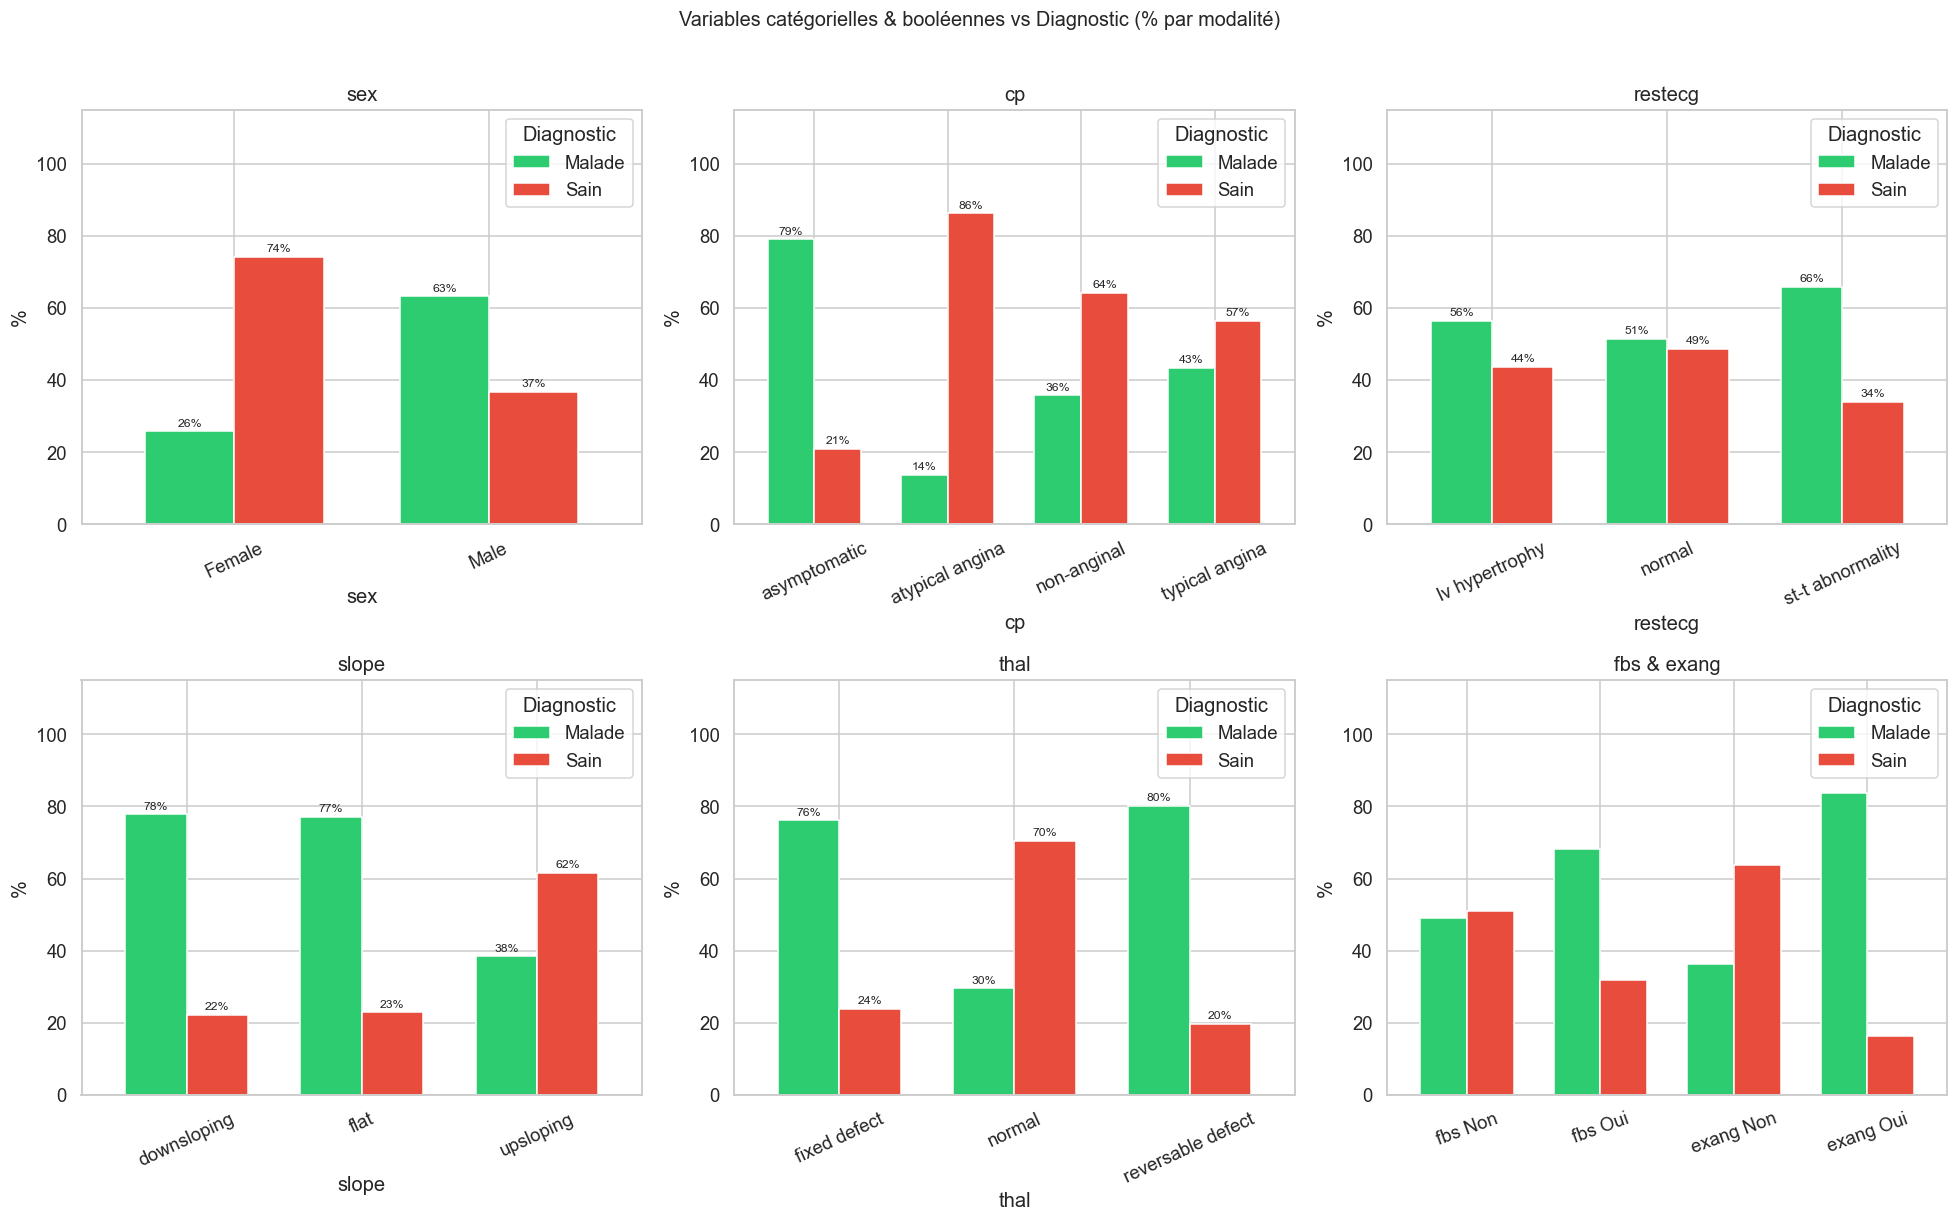

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))  # grille de graphiques
axes_list = list(axes.flat)

for i, col in enumerate(CAT_COLS):
    ax = axes_list[i]
    ct = df.groupby([col, 'target_label']).size().unstack(fill_value=0)  # tableau croisé
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100  # conversion en %
    ct_pct.plot(kind='bar', ax=ax, color=[C['sain'], C['malade']],
                edgecolor='white', width=0.7)
    ax.set_title(col)
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Diagnostic')
    ax.set_ylim(0, 115)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', fontsize=8, padding=2)  # afficher %

# fbs et exang sur le dernier axe
ax = axes_list[5]
df_bool = df.copy()
df_bool['fbs']   = df_bool['fbs'].map({True:'fbs Oui', False:'fbs Non', 1:'fbs Oui', 0:'fbs Non'})  # mapping
df_bool['exang'] = df_bool['exang'].map({True:'exang Oui', False:'exang Non', 1:'exang Oui', 0:'exang Non'})
ct_bool = pd.concat([
    df_bool.groupby(['fbs',   'target_label']).size().unstack(fill_value=0),
    df_bool.groupby(['exang', 'target_label']).size().unstack(fill_value=0)
])
ct_bool_pct = ct_bool.div(ct_bool.sum(axis=1), axis=0) * 100  # %
ct_bool_pct.plot(kind='bar', ax=ax, color=[C['sain'], C['malade']],
                 edgecolor='white', width=0.7)
ax.set_title('fbs & exang')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Diagnostic')
ax.set_ylim(0, 115)

plt.suptitle('Variables catégorielles & booléennes vs Diagnostic (% par modalité)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_PATH / '05_cat_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Matrice de corrélation

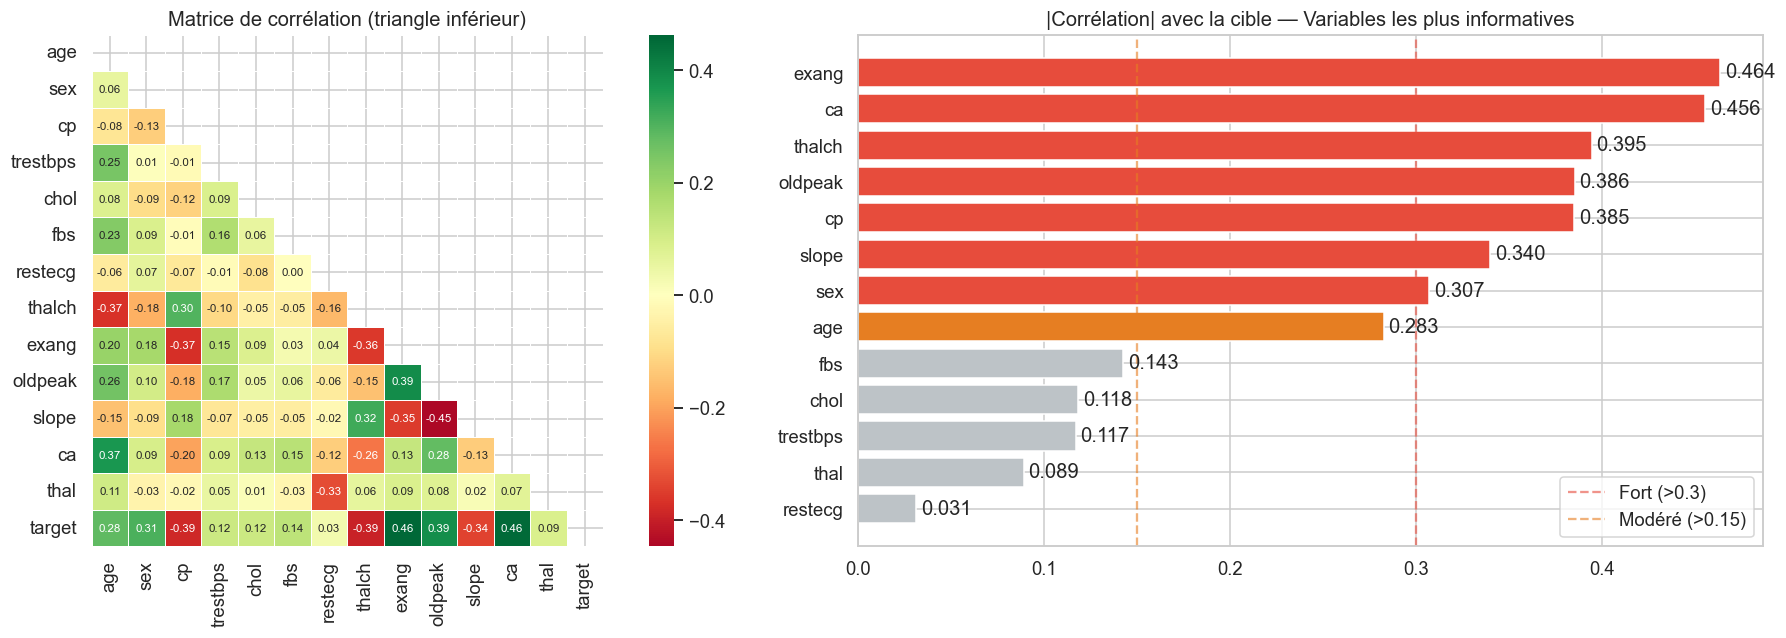


Top 6 features corrélées avec la cible :
exang      0.463619
ca         0.455599
thalch     0.394503
oldpeak    0.385528
cp         0.385077
slope      0.339925


In [28]:
df_enc = df.copy()  # copie du dataset

# Corriger les valeurs aberrantes avant calcul de corrélation
df_enc.loc[df_enc['chol'] == 0, 'chol'] = np.nan
df_enc.loc[df_enc['trestbps'] == 0, 'trestbps'] = np.nan

# Encodage des variables catégorielles
for col in CAT_COLS + ['dataset']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

# Encodage des variables booléennes
df_enc['fbs']   = df_enc['fbs'].map({True:1, False:0, 'True':1, 'False':0}).astype(float)
df_enc['exang'] = df_enc['exang'].map({True:1, False:0, 'True':1, 'False':0}).astype(float)

# Colonnes utilisées pour la corrélation
cols_corr = ['age','sex','cp','trestbps','chol','fbs','restecg',
             'thalch','exang','oldpeak','slope','ca','thal','target']

corr = df_enc[cols_corr].corr()  # matrice de corrélation

fig, axes = plt.subplots(1, 2, figsize=(18, 6))  # 2 graphiques

# Heatmap (triangle inférieur)
mask = np.triu(np.ones_like(corr, dtype=bool))  # masque triangle supérieur
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.4, ax=axes[0],
            annot_kws={'size': 7.5})
axes[0].set_title('Matrice de corrélation (triangle inférieur)')

# Corrélation avec la cible
corr_t = corr['target'].drop('target').abs().sort_values()  # valeur absolue
bar_colors = ['#e74c3c' if v > 0.3 else '#e67e22' if v > 0.15 else '#bdc3c7'
              for v in corr_t]

bars = axes[1].barh(corr_t.index, corr_t.values, color=bar_colors, edgecolor='white')
axes[1].bar_label(bars, fmt='%.3f', padding=3)

# seuils de corrélation
axes[1].axvline(0.3, color='#e74c3c', linestyle='--', alpha=0.6, label='Fort (>0.3)')
axes[1].axvline(0.15, color='#e67e22', linestyle='--', alpha=0.6, label='Modéré (>0.15)')

axes[1].set_title('|Corrélation| avec la cible — Variables les plus informatives')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGS_PATH / '06_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 6 features corrélées avec la cible :')
print(corr_t.tail(6).sort_values(ascending=False).to_string())

### 8. Analyse par centre (dataset)

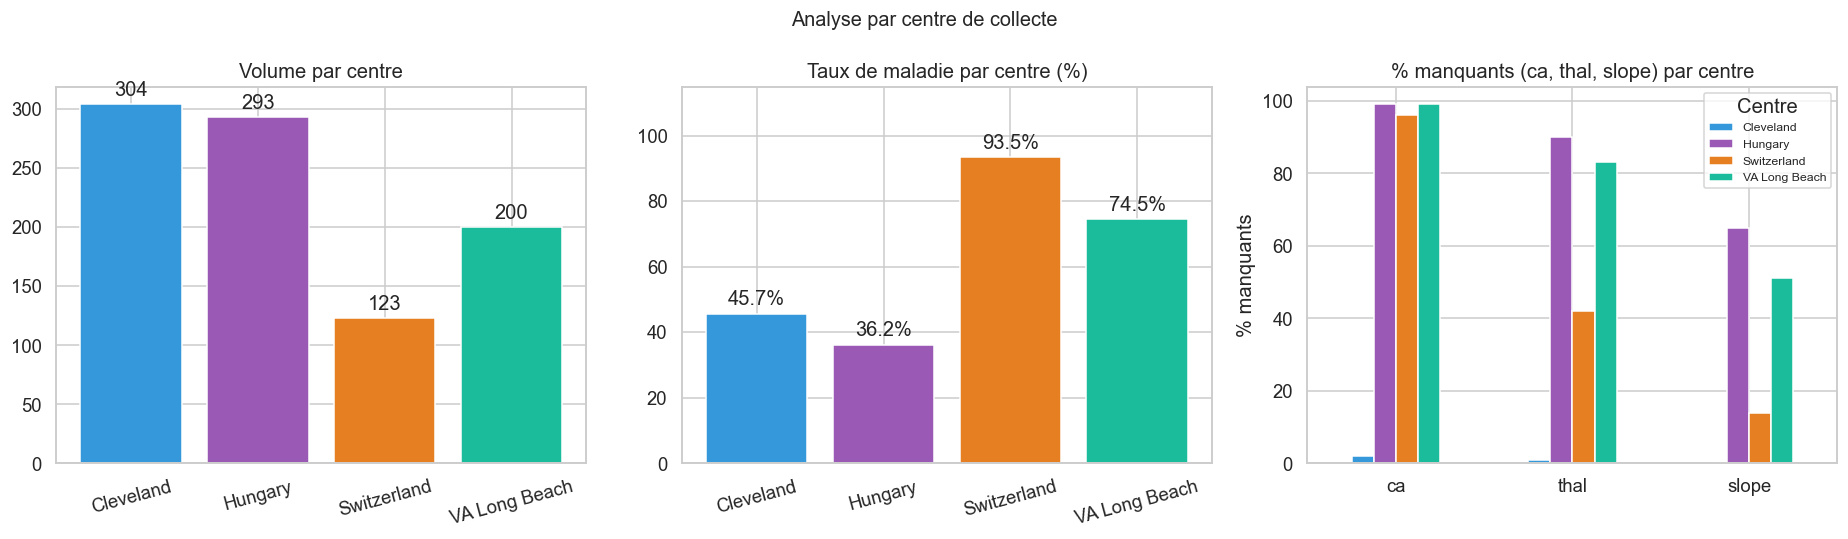


→ Switzerland & VA Long Beach ont quasi 100% de manquants sur ca/thal/slope
→ dataset est une feature importante à garder (OHE)


In [29]:
centres = ['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
palette_centres = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))  # 3 graphiques

# Volume par centre
vol = df['dataset'].value_counts().reindex(centres)
axes[0].bar(vol.index, vol.values, color=palette_centres, edgecolor='white')
axes[0].bar_label(axes[0].containers[0], padding=3)
axes[0].set_title('Volume par centre')
axes[0].tick_params(axis='x', rotation=15)

# Taux de maladie par centre
rate = df.groupby('dataset')['target'].mean().reindex(centres) * 100
bars = axes[1].bar(rate.index, rate.values, color=palette_centres, edgecolor='white')
axes[1].bar_label(bars, fmt='%.1f%%', padding=3)
axes[1].set_title('Taux de maladie par centre (%)')
axes[1].set_ylim(0, 115)
axes[1].tick_params(axis='x', rotation=15)

# % valeurs manquantes par centre
miss_centre = df.groupby('dataset')[['ca','thal','slope']].apply(lambda x: x.isnull().mean()*100).round(0)
miss_centre.T.plot(kind='bar', ax=axes[2], color=palette_centres, edgecolor='white')
axes[2].set_title('% manquants (ca, thal, slope) par centre')
axes[2].set_ylabel('% manquants')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Centre', fontsize=8)

plt.suptitle('Analyse par centre de collecte', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_PATH / '07_by_centre.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Switzerland & VA Long Beach ont quasi 100% de manquants sur ca/thal/slope')
print('→ dataset est une feature importante à garder (OHE)')

### 9. Résumé des problèmes détectés

In [30]:
problemes = {
    'Valeurs aberrantes': [
        f'chol = 0        → {(df_raw["chol"]==0).sum()} cas  → remplacer par NaN puis imputer la médiane',
        f'trestbps = 0    → {(df_raw["trestbps"]==0).sum()} cas   → remplacer par NaN puis imputer la médiane',
        f'oldpeak < 0     → {(df_raw["oldpeak"]<0).sum()} cas  → remplacer par 0 (aucune dépression ST)',
    ],
    'Valeurs manquantes': [
        'ca     66.4%  → SimpleImputer(médiane)  + flag binaire  ca_missing',
        'thal   52.8%  → SimpleImputer(mode)     + flag binaire  thal_missing',
        'slope  33.6%  → SimpleImputer(mode)',
        'autres < 10%  → SimpleImputer(médiane ou mode selon le type)',
    ],
    'Encodage': [
        'cp, thal, dataset          → OneHotEncoder (variables nominales)',
        'sex, restecg, slope        → LabelEncoder',
        'fbs, exang                 → True/False → 0/1 (cast manuel)',
    ],
    'Normalisation': [
        'RobustScaler sur variables numériques (résistant aux outliers résiduels)',
    ],
    'Déséquilibre de classes': [
        f'Train : 329 sains / 407 malades → SMOTE appliqué sur train uniquement',
    ],
    'Feature engineering': [
        'chol_per_age  = chol / age           (cholestérol relatif à l\'âge)',
        'thalch_ratio  = thalch / (220 - age) (% fréquence cardiaque max théorique)',
    ]
}

for section, items in problemes.items():
    print(f'\n[{section}]')
    for item in items:
        print(f'   • {item}')

print('\n→ Voir scripts/preprocess.py pour l\'implémentation complète')


[Valeurs aberrantes]
   • chol = 0        → 172 cas  → remplacer par NaN puis imputer la médiane
   • trestbps = 0    → 1 cas   → remplacer par NaN puis imputer la médiane
   • oldpeak < 0     → 12 cas  → remplacer par 0 (aucune dépression ST)

[Valeurs manquantes]
   • ca     66.4%  → SimpleImputer(médiane)  + flag binaire  ca_missing
   • thal   52.8%  → SimpleImputer(mode)     + flag binaire  thal_missing
   • slope  33.6%  → SimpleImputer(mode)
   • autres < 10%  → SimpleImputer(médiane ou mode selon le type)

[Encodage]
   • cp, thal, dataset          → OneHotEncoder (variables nominales)
   • sex, restecg, slope        → LabelEncoder
   • fbs, exang                 → True/False → 0/1 (cast manuel)

[Normalisation]
   • RobustScaler sur variables numériques (résistant aux outliers résiduels)

[Déséquilibre de classes]
   • Train : 329 sains / 407 malades → SMOTE appliqué sur train uniquement

[Feature engineering]
   • chol_per_age  = chol / age           (cholestérol relatif à l